In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.config import INTERIM_DATA

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

# Load Data

In [31]:
df = pd.read_csv(INTERIM_DATA, encoding="ISO-8859-1")
df.shape

(1067371, 8)

In [32]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [34]:
missing = df.isnull().sum()
missing_percentage = (missing/len(df)) * 100
pd.DataFrame(
    {
        "missing_count": missing,
        "missing_percentage": missing_percentage.round(2)
    }
).sort_values("missing_percentage", ascending=False)

,missing_count,missing_percentage
Customer ID,243007,22.77
Description,4382,0.41
Invoice,0,0.00
StockCode,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


In [35]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [36]:
df["is_cancelled"] = df["Invoice"].astype(str).str.startswith("C")
df["is_cancelled"].value_counts()

is_cancelled
False    1047877
True       19494
Name: count, dtype: int64

In [43]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count} ({duplicate_count/len(df)*100:.2f}%)")

Duplicate rows: 34335 (3.22%)


In [44]:
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


In [45]:
def iqr_outlier_summary(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"{name}: {len(outliers)} outliers ({len(outliers)/len(series)*100:.2f}%) | bounds: [{lower:.2f}, {upper:.2f}]")

iqr_outlier_summary(df["Quantity"], "Quantity")
iqr_outlier_summary(df["Price"], "Price")
iqr_outlier_summary(df["Revenue"], "Revenue")

Quantity: 116489 outliers (10.91%) | bounds: [-12.50, 23.50]
Price: 68105 outliers (6.38%) | bounds: [-3.10, 8.50]
Revenue: 90922 outliers (8.52%) | bounds: [-17.18, 38.63]


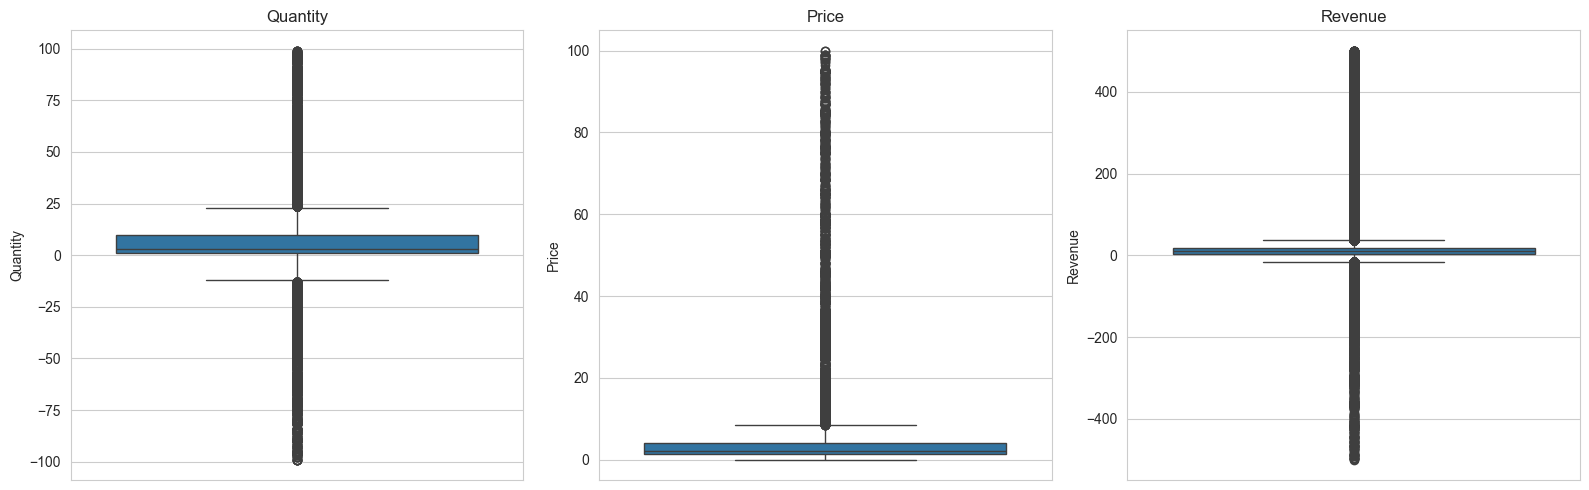

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(y=df[(df["Quantity"] > -100) & (df["Quantity"] < 100)]["Quantity"], ax=axes[0])
axes[0].set_title("Quantity")
sns.boxplot(y=df[(df["Price"] > 0) & (df["Price"] < 100)]["Price"], ax=axes[1])
axes[1].set_title("Price")
sns.boxplot(y=df[(df["Revenue"] > -500) & (df["Revenue"] < 500)]["Revenue"], ax=axes[2])
axes[2].set_title("Revenue")
plt.tight_layout()
plt.show()

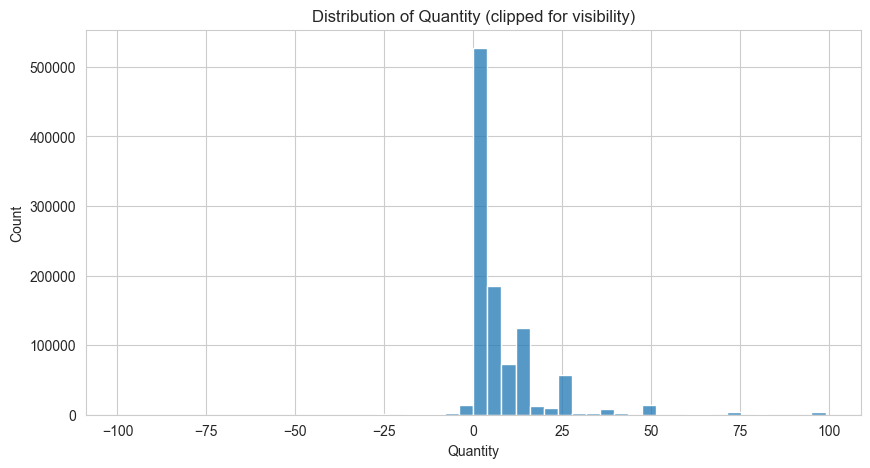

In [37]:
plt.figure()
sns.histplot(df[(df["Quantity"] > -100) & (df["Quantity"] < 100)]["Quantity"], bins=50)
plt.title("Distribution of Quantity (clipped for visibility)")
plt.show()

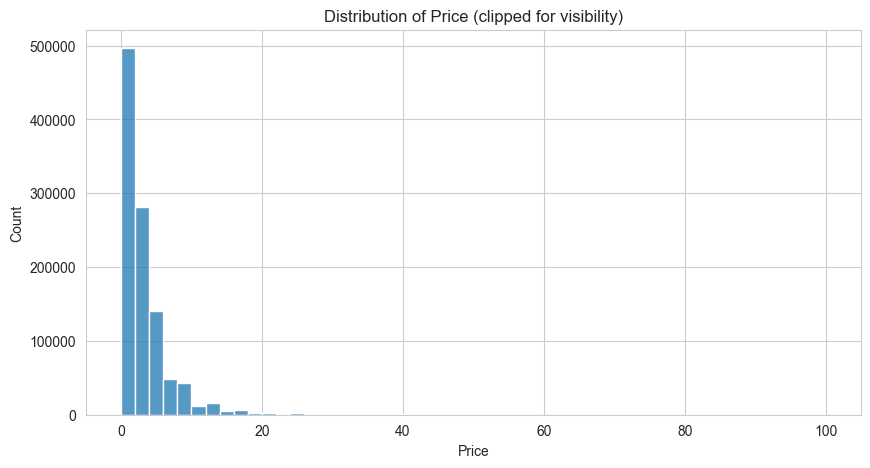

In [38]:
plt.figure()
sns.histplot(df[(df["Price"] > 0) & (df["Price"] < 100)]["Price"], bins=50)
plt.title("Distribution of Price (clipped for visibility)")
plt.show()

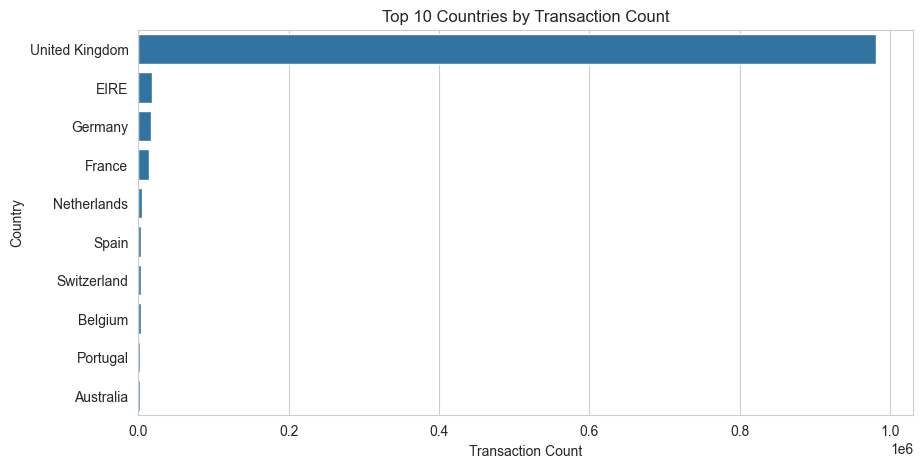

In [39]:
top_countries = df["Country"].value_counts().head(10)
plt.figure()
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Transaction Count")
plt.xlabel("Transaction Count")
plt.show()

# Bivariate Analysis

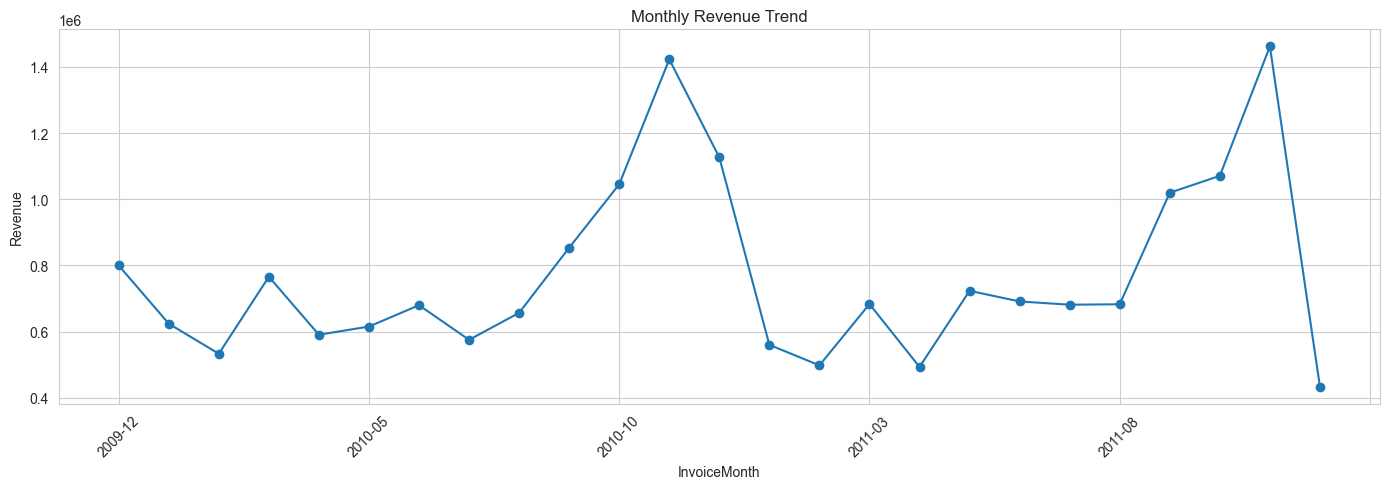

In [47]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

df["Revenue"] = df["Quantity"] * df["Price"]

monthly_revenue = df.groupby("InvoiceMonth")["Revenue"].sum()

plt.figure(figsize=(14,5))
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
total_customers = df["Customer ID"].nunique()
print(f"Total unique customers: {total_customers}")
orders_per_customer = df.groupby("Customer ID")["Invoice"].nunique()
repeat_customers = (orders_per_customer > 1).sum()
print(f"Customers with more than 1 order: {repeat_customers} ({repeat_customers/total_customers*100:.1f}%)")

Total unique customers: 5942
Customers with more than 1 order: 4481 (75.4%)


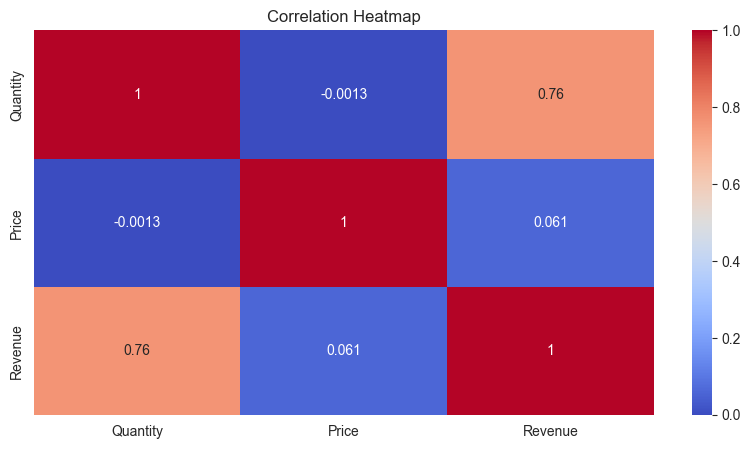

In [42]:
numeric_cols = df[["Quantity", "Price", "Revenue"]]
plt.figure()
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

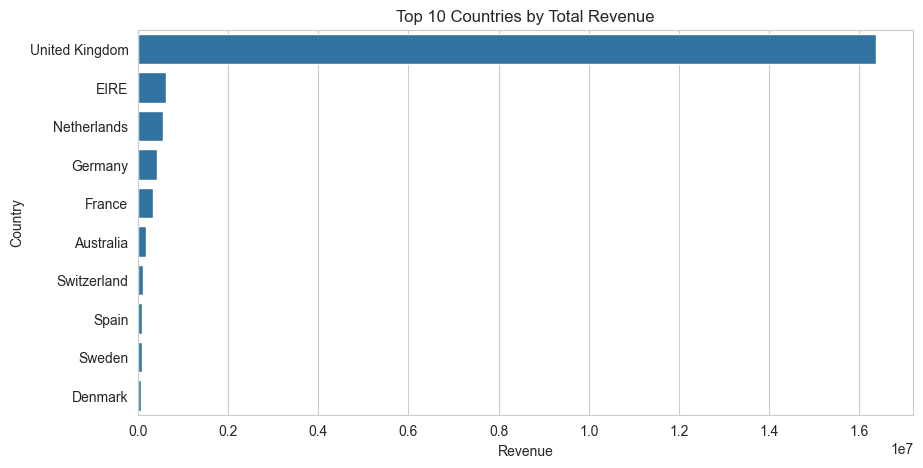

In [50]:
revenue_by_country = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
plt.figure()
sns.barplot(
    x=revenue_by_country.values,
    y=revenue_by_country.index
)
plt.title("Top 10 Countries by Total Revenue")
plt.xlabel("Revenue")
plt.show()

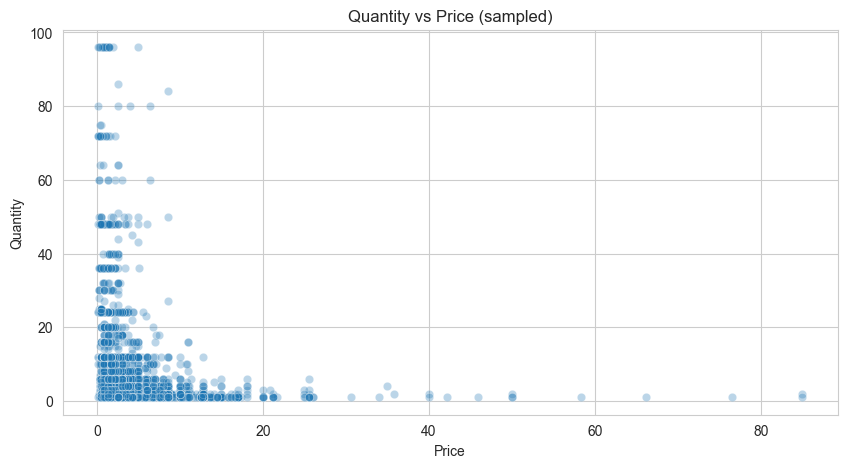

In [53]:
sample = df[(df["Quantity"] > 0) & (df["Quantity"] < 100) & (df["Price"] > 0) & (df["Price"] < 100)].sample(5000, random_state=42)
plt.figure()
sns.scatterplot(data=sample, x="Price", y="Quantity", alpha=0.3)
plt.title("Quantity vs Price (sampled)")
plt.show()

is_cancelled
False    459.103547
True    -184.113345
Name: Revenue, dtype: float64


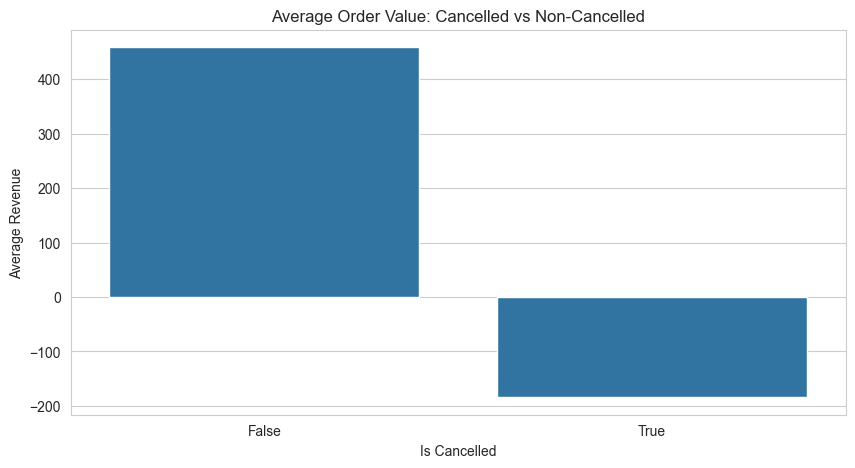

In [58]:
order_value = df.groupby(["Invoice", "is_cancelled"])["Revenue"].sum().reset_index()
avg_by_cancel = order_value.groupby("is_cancelled")["Revenue"].mean()
print(avg_by_cancel)

plt.figure()
sns.barplot(
    x=avg_by_cancel.index.astype(str),
    y=avg_by_cancel.values
)
plt.title("Average Order Value: Cancelled vs Non-Cancelled")
plt.ylabel("Average Revenue")
plt.xlabel("Is Cancelled")
plt.show()

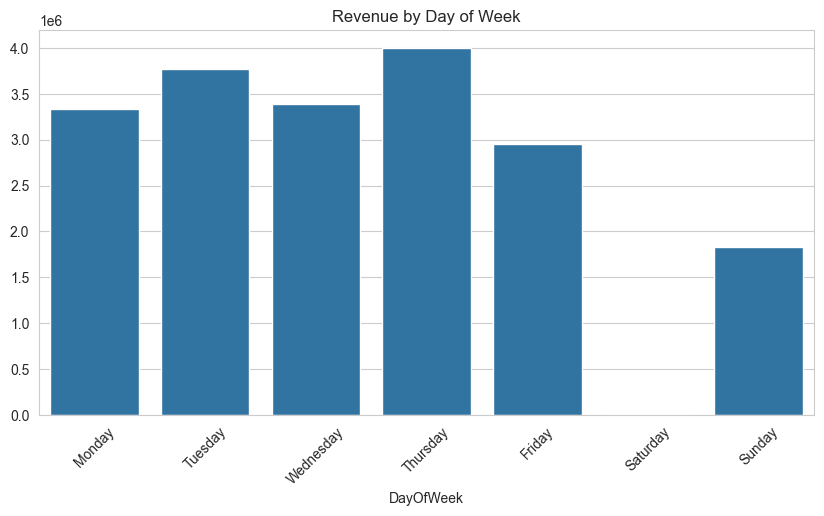

In [60]:
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
revenue_by_day = df.groupby("DayOfWeek")["Revenue"].sum().reindex(day_order)

plt.figure()
sns.barplot(x=revenue_by_day.index, y=revenue_by_day.values)
plt.title("Revenue by Day of Week")
plt.xticks(rotation=45)
plt.show()

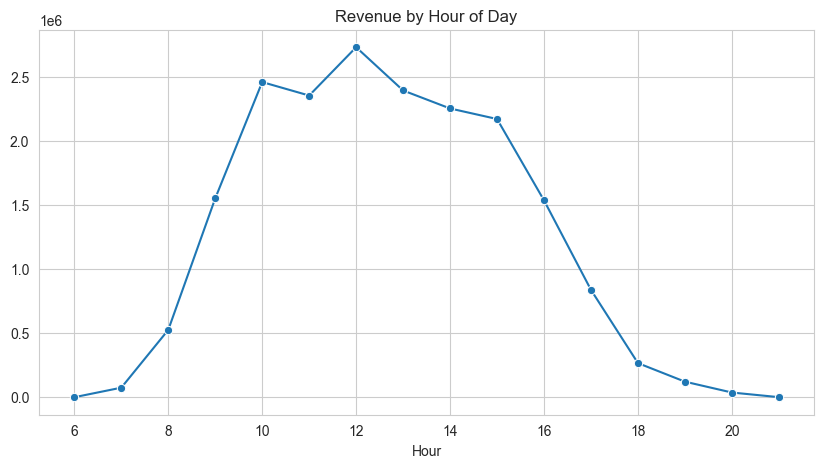

In [61]:
revenue_by_hour = df.groupby("Hour")["Revenue"].sum()
plt.figure()
sns.lineplot(x=revenue_by_hour.index, y=revenue_by_hour.values, marker="o")
plt.title("Revenue by Hour of Day")
plt.show()

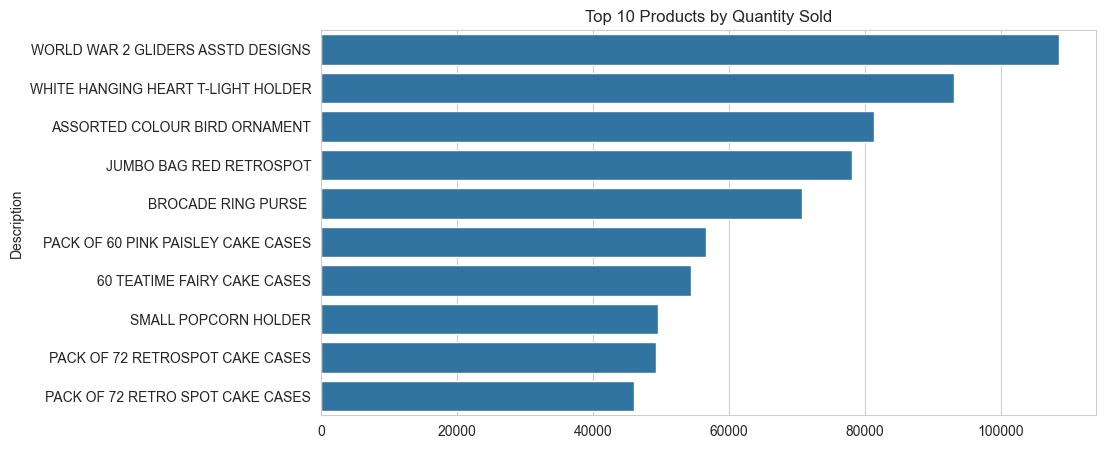

In [62]:
top_products_qty = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
plt.figure()
sns.barplot(x=top_products_qty.values, y=top_products_qty.index)
plt.title("Top 10 Products by Quantity Sold")
plt.show()

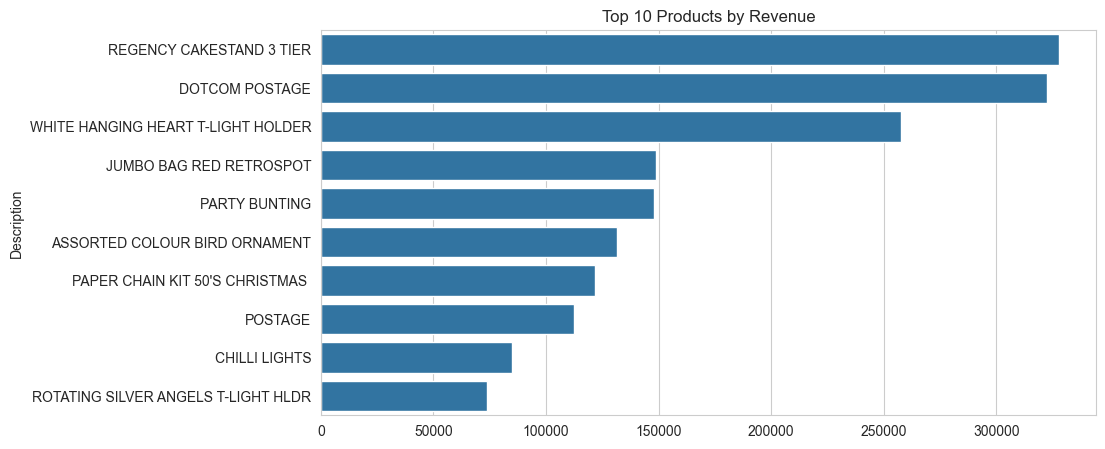

In [63]:
top_products_rev = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
plt.figure()
sns.barplot(x=top_products_rev.values, y=top_products_rev.index)
plt.title("Top 10 Products by Revenue")
plt.show()

# Multivariate Analysis

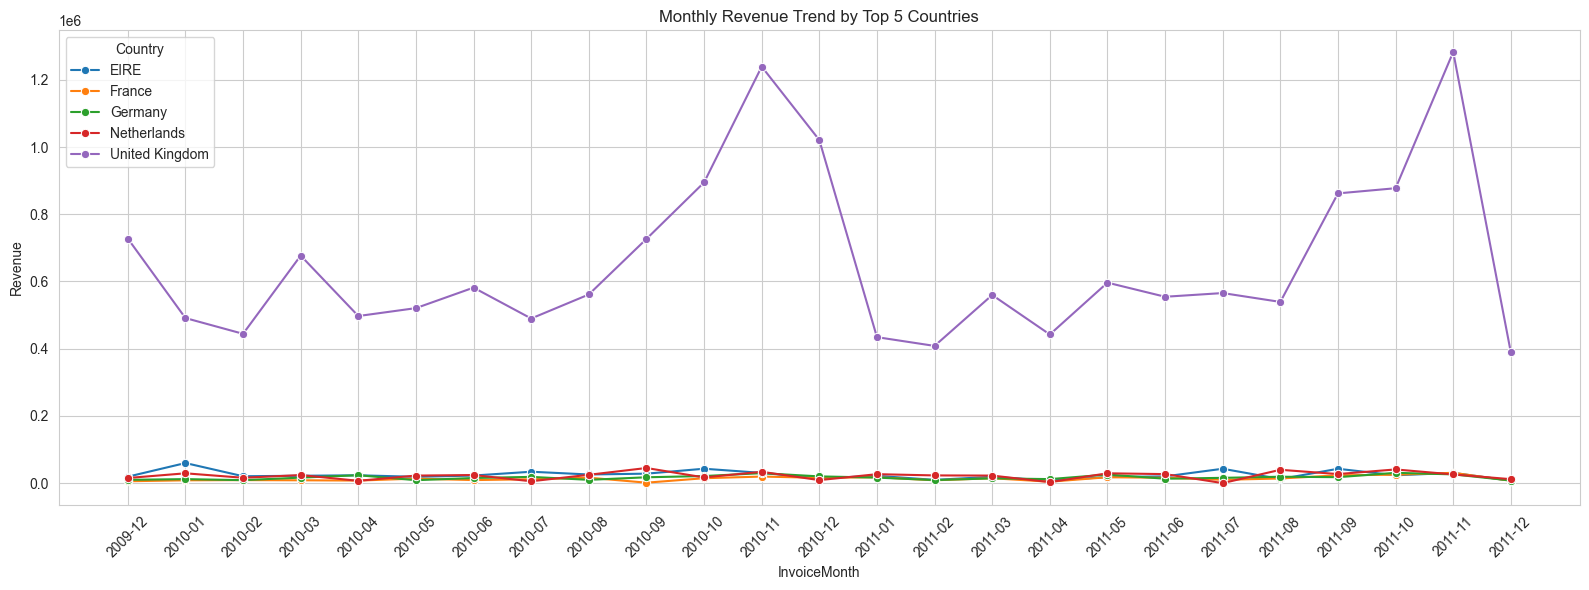

In [64]:
top5_countries = df["Country"].value_counts().head(5).index
subset = df[df["Country"].isin(top5_countries)]

monthly_by_country = subset.groupby(["InvoiceMonth", "Country"])["Revenue"].sum().reset_index()

plt.figure(figsize=(16, 6))
sns.lineplot(data=monthly_by_country, x="InvoiceMonth", y="Revenue", hue="Country", marker="o")
plt.title("Monthly Revenue Trend by Top 5 Countries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

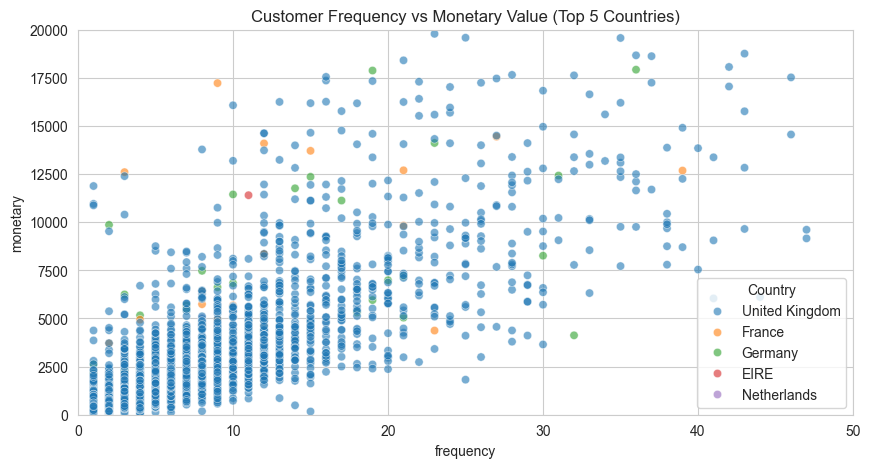

In [65]:
customer_summary = df[df["is_cancelled"] == False].groupby(["Customer ID", "Country"]).agg(
    frequency=("Invoice", "nunique"),
    monetary=("Revenue", "sum")
).reset_index()

top5_customer_summary = customer_summary[customer_summary["Country"].isin(top5_countries)]

plt.figure()
sns.scatterplot(data=top5_customer_summary, x="frequency", y="monetary", hue="Country", alpha=0.6)
plt.title("Customer Frequency vs Monetary Value (Top 5 Countries)")
plt.xlim(0, 50)
plt.ylim(0, 20000)
plt.show()

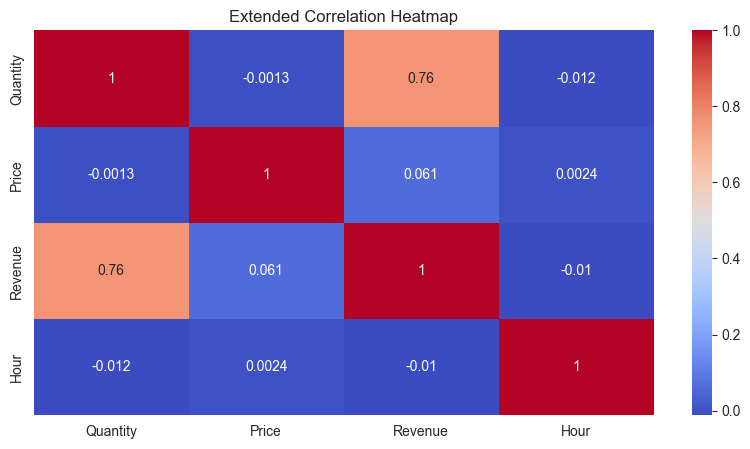

In [66]:
corr_features = df[["Quantity", "Price", "Revenue", "Hour"]]
plt.figure()
sns.heatmap(corr_features.corr(), annot=True, cmap="coolwarm")
plt.title("Extended Correlation Heatmap")
plt.show()

## EDA Summary

- Dataset spans **2009-12-01** to **2011-12-09**, covering **1,067,371** transactions
- **22.77%** of rows are missing Customer ID (243,007 rows) — will be dropped in the cleaning step, since churn/RFM analysis requires a known customer
- **0.41%** of rows are missing Description (4,382 rows) — minor, can be dropped or left as "Unknown"
- **3.22%** of rows are exact duplicates (34,335 rows) — will be removed during cleaning
- **1.83%** of invoices are cancellations (19,494 of 1,067,371 rows, Invoice starting with 'C')
- Outlier analysis (IQR method) shows meaningful skew in transaction-level data: **10.91%** of Quantity values, **6.38%** of Price values, and **8.52%** of Revenue values fall outside IQR bounds — mostly driven by bulk/wholesale orders and a handful of high-value transactions
- Cancelled orders have a **negative average order value (-£184.11)**, as expected — while completed orders average **£459.10** per invoice, confirming cancellations should be excluded from revenue/RFM monetary calculations
- **5,942** unique customers in the dataset, of which **75.4%** (4,481) placed more than one order — indicating a strongly repeat-driven customer base rather than a one-time-buyer-heavy business
- Revenue is heavily concentrated in the **United Kingdom**, both by transaction count and by total revenue, consistent with the dataset's UK e-commerce origin
- Quantity and Price show negative correlation at the transaction level — higher-priced items tend to be purchased in smaller quantities, a typical retail pattern (bulk-buying is concentrated in low-cost items)
- Revenue shows clear month-to-month variation across the two-year window, with the multi-country breakdown confirming the UK drives the overall trend while other top-5 markets contribute comparatively minor, flatter revenue lines
- Top products by **quantity sold** differ from top products by **revenue generated** — high-volume items are not necessarily the highest earners, which matters for inventory vs. profitability prioritization later